# Iris Flower Classification



In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## About Dataset
### Context

The Iris flower data set is a multivariate data set introduced by the British statistician and biologist Ronald Fisher in his 1936 paper The use of multiple measurements in taxonomic problems. It is sometimes called Anderson's Iris data set because Edgar Anderson collected the data to quantify the morphologic variation of Iris flowers of three related species. The data set consists of 50 samples from each of three species of Iris (Iris Setosa, Iris virginica, and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

This dataset became a typical test case for many statistical classification techniques in machine learning such as support vector machines

### Content
- The dataset contains a set of 150 records under 5 attributes - Petal Length, Petal Width, Sepal Length, Sepal width and Class(Species).

####  Acknowledgements
This dataset is free and is publicly available at the UCI Machine Learning Repository.

In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [14]:
print(df['species'].unique())
print('features = ', df.columns[0:4].values)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
features =  ['sepal_length' 'sepal_width' 'petal_length' 'petal_width']


## Multiclass classification


In [11]:
iris_labels = ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


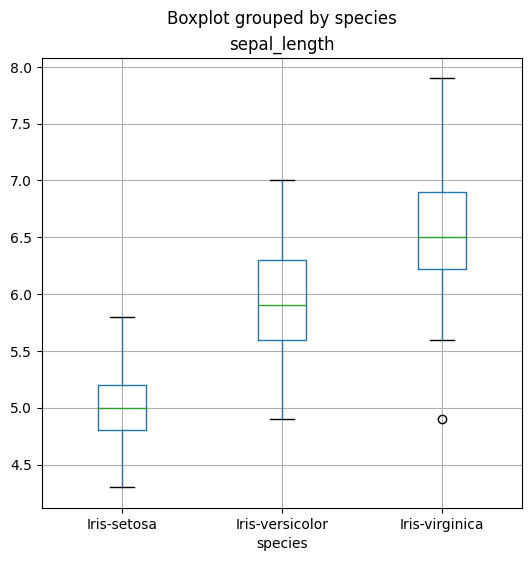

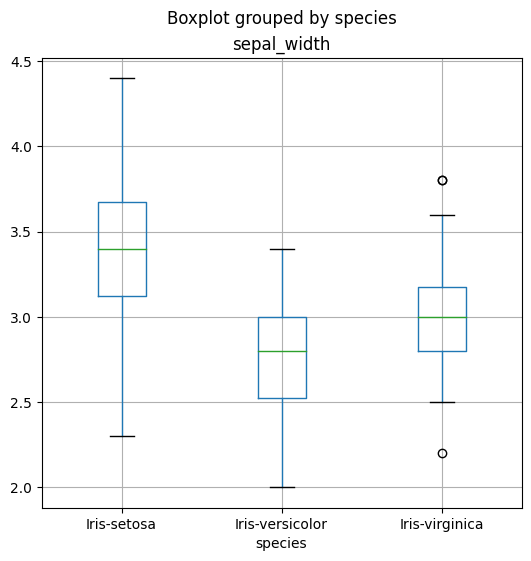

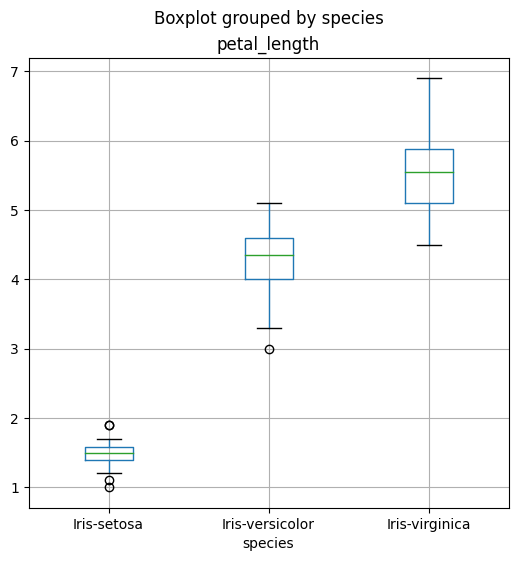

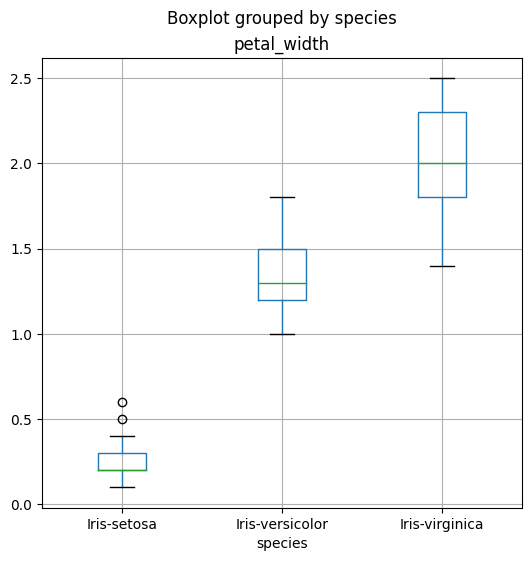

In [29]:
%matplotlib inline

iris_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
iris_label = 'species'

for col in iris_features:
  df.boxplot(column=col, by=iris_label, figsize=(6,6))
  plt.title(col)

plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X, y = df[iris_features].values, df[iris_label].values

# split data 70-30 into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

print('Training set %d , Test set %d \n' % (X_train.shape[0], X_test.shape[0]))


Training set 105 , Test set 45 



In [32]:
from sklearn.linear_model import LogisticRegression

reg = 0.1 # set regularization rate

# train model on training set
multi_model = LogisticRegression(C=1/reg, solver='lbfgs', multi_class='auto', max_iter=10000).fit(X_train, y_train)
print(multi_model)

LogisticRegression(C=10.0, max_iter=10000)


In [33]:
iris_predictions = multi_model.predict(X_test)
print('Predicted labels: ', iris_predictions[:15])
print('Actual labels: ', y_test[:15])

Predicted labels:  ['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor']
Actual labels:  ['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor']


In [34]:
# let's look at classification report.
from sklearn.metrics import classification_report

print(classification_report(y_test, iris_predictions))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        15
 Iris-virginica       1.00      1.00      1.00        15

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print('Overall accuracy: ', accuracy_score(y_test, iris_predictions))
print('Overall precision: ', precision_score(y_test, iris_predictions, average='macro'))
print('Overall recall: ', recall_score(y_test, iris_predictions, average='macro'))


Overall accuracy:  1.0
Overall precision:  1.0
Overall recall:  1.0


In [37]:
from sklearn.metrics import confusion_matrix
# Print the confusion matrix
mcm = confusion_matrix(y_test, iris_predictions)
print(mcm)

[[15  0  0]
 [ 0 15  0]
 [ 0  0 15]]


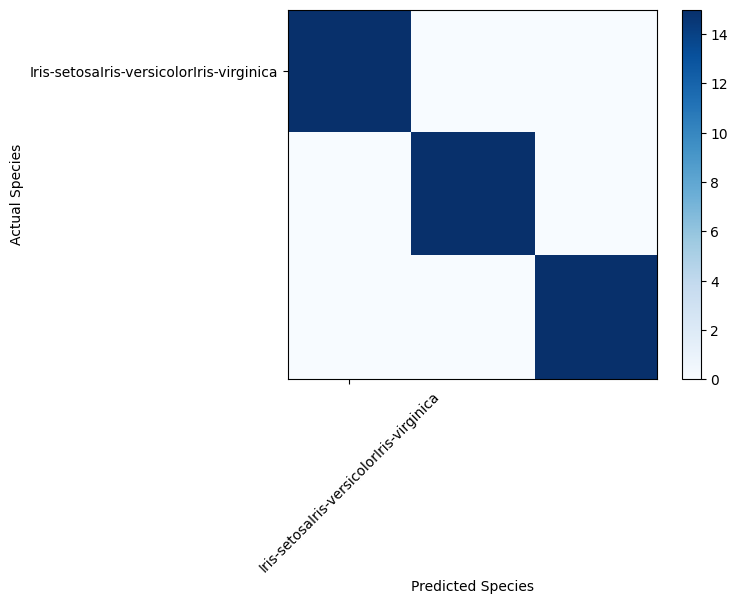

In [38]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(iris_labels))
plt.xticks(tick_marks, iris_labels, rotation=45)
plt.yticks(tick_marks, iris_labels)
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

In [39]:
iris_labels

['Iris-setosaIris-versicolorIris-virginica']

In [52]:
# from sklearn.metrics import roc_curve
# from sklearn.metrics import roc_auc_score

# # get class probability scores
# iris_prob = multi_model.predict_proba(X_test)

# iset = {}
# iver = {}
# ivir = {}

# for i in range(len(iris_labels)):
#   iset[i], iver[i], ivir[i] = roc_curve(y_test, iris_prob[:, i], pos_label=i )

# # Plot the ROC chart
# plt.plot(iset[0], iver[0], linestyle='--',color='orange', label=iris_labels[0] + ' vs Rest')
# plt.plot(iset[1], iver[1], linestyle='--',color='green', label=iris_labels[1] + ' vs Rest')
# plt.plot(iset[2], iver[2], linestyle='--',color='blue', label=iris_labels[2] + ' vs Rest')
# plt.title('Multiclass ROC curve')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive rate')
# plt.legend(loc='best')
# plt.show()


In [53]:
# auc = roc_auc_score(y_test, iris_prob, multi_class='ovr')
# print('Average AUC: ', auc)

### Preprocess data in a pipeline

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

feature_cols = [0, 1, 2, 3]
feature_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('preprocess', feature_transformer, feature_cols)
    ]
)

# create training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', SVC(probability=True))])

# fit pipeline to train linear regression model
multi_model = pipeline.fit(X_train, y_train)
print(multi_model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('preprocess',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3])])),
                ('regressor', SVC(probability=True))])


Overall Accuracy: 0.9777777777777777
Overall Precision: 0.9791666666666666
Overall Recall: 0.9777777777777779
Average AUC: 1.0


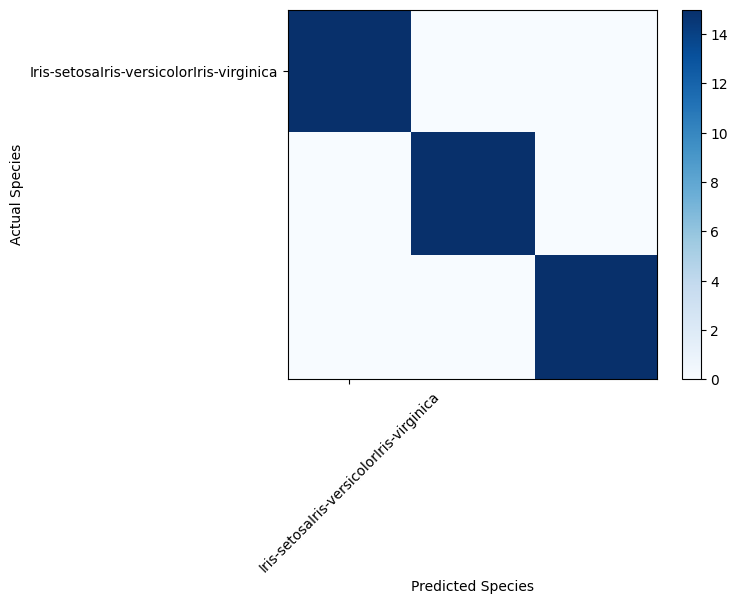

In [57]:
from sklearn.metrics import roc_auc_score

# get predictions from test data
iris_predictions = multi_model.predict(X_test)
iris_prob = multi_model.predict_proba(X_test)

# overall metrics
print("Overall Accuracy:",accuracy_score(y_test, iris_predictions))
print("Overall Precision:",precision_score(y_test, iris_predictions, average='macro'))
print("Overall Recall:",recall_score(y_test, iris_predictions, average='macro'))
print('Average AUC:', roc_auc_score(y_test, iris_prob, multi_class='ovr'))

# confusion matrix
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(iris_labels))
plt.xticks(tick_marks, iris_labels, rotation=45)
plt.yticks(tick_marks, iris_labels)
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()


In [58]:
# save model and use for later
import joblib
filename = 'iris_model.pkl'
joblib.dump(multi_model, filename)


['iris_model.pkl']

In [59]:
multi_model = joblib.load(filename)

x_new = np.array([[4.5, 3.1, 5.5, 0.1]])
print('New sample: {}'.format(x_new[0]))

iris_pred = multi_model.predict(x_new)[0]
print('Predicted class: ', iris_pred)


New sample: [4.5 3.1 5.5 0.1]
Predicted class:  Iris-setosa


In [60]:
# use 2 feature arrays
x_new = np.array([[4.1, 2.9, 5.2, 0.3], [5.6, 3.6, 4.2, 0.2]])
print('New sample: {}'.format(x_new))

preds = multi_model.predict(x_new)
for pred in preds:
  print(pred)


New sample: [[4.1 2.9 5.2 0.3]
 [5.6 3.6 4.2 0.2]]
Iris-versicolor
Iris-setosa


### Other Models for Multiclass Classification

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [62]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species")
fig.show()

In [63]:
x = df.drop('species', axis=1)
y = df['species']

### KNN

In [64]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)

preds = knn.predict(x_test)

In [65]:
accuracy = knn.score(x_test, y_test)
print(accuracy)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, preds)
cm

1.0


array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])

In [66]:
x_test_new = np.array([[6.5, 3.1, 5.3, 1.5]])
pred = knn.predict(x_test_new)
pred

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but KNeighborsClassifier was fitted with feature names



array(['Iris-virginica'], dtype=object)

In [67]:
x_test_new = np.array([[3.5, 1.1, 3.3, 2.2]])
pred = knn.predict(x_test_new)
pred

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but KNeighborsClassifier was fitted with feature names



array(['Iris-versicolor'], dtype=object)

### Naive bayes classifier

In [68]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(x_train, y_train)
model_preds = model.predict(x_test)
# print(list(model_preds))

In [69]:
accuracy = model.score(x_test, y_test)
print(accuracy)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, model_preds)
cm

0.9666666666666667


array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  1,  5]])

In [70]:
x_test_new = np.array([[6.5, 3.1, 5.3, 1.5]])
pred = model.predict(x_test_new)
pred

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but GaussianNB was fitted with feature names



array(['Iris-virginica'], dtype='<U15')

In [71]:
x_test_new = np.array([[3.5, 1.1, 3.3, 2.2]])
pred = model.predict(x_test_new)
pred

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but GaussianNB was fitted with feature names



array(['Iris-versicolor'], dtype='<U15')